In [9]:
import random
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [10]:
def read_tif_rgb(path):
    with rasterio.open(path) as src:
        arr = src.read()  # (bands, H, W)

    # Use first 3 bands for RGB visualization
    rgb = arr[:3].transpose(1, 2, 0).astype(np.float32)

    # Robust normalization
    lo = np.percentile(rgb, 2)
    hi = np.percentile(rgb, 98)
    if hi <= lo:
        hi = lo + 1.0
    rgb = (rgb - lo) / (hi - lo)
    rgb = np.clip(rgb, 0, 1)
    return rgb


def parse_yolo_labels(label_path):
    boxes = []
    if not label_path.exists():
        return boxes

    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue
        cls, xc, yc, w, h = map(float, line.split())
        boxes.append((int(cls), xc, yc, w, h))
    return boxes


def yolo_to_pixel(box, W, H):
    cls, xc, yc, w, h = box
    bw = w * W
    bh = h * H
    x0 = xc * W - bw / 2
    y0 = yc * H - bh / 2
    return cls, x0, y0, bw, bh


def show_chip_with_labels(
    tif_path,
    label_path,
    class_names=None,
):
    from pathlib import Path
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    tif_path = Path(tif_path)
    label_path = Path(label_path)

    rgb = read_tif_rgb(tif_path)
    H, W = rgb.shape[:2]
    boxes = parse_yolo_labels(label_path)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(rgb)
    ax.set_title(f"{tif_path.name}  |  {len(boxes)} boxes")
    ax.axis("off")

    for box in boxes:
        cls, x0, y0, bw, bh = yolo_to_pixel(box, W, H)

        # Thin red bbox
        rect = Rectangle(
            (x0, y0),
            bw,
            bh,
            fill=False,
            edgecolor="red",
            linewidth=0.8,
            alpha=0.9
        )
        ax.add_patch(rect)

        # Class label
        if class_names and cls in class_names:
            label_text = class_names[cls]
        else:
            label_text = str(cls)

        ax.text(
            x0,
            y0,
            label_text,
            fontsize=9,
            color="black",
            verticalalignment="top",
            horizontalalignment="left",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.5,
                pad=2
            )
        )

    plt.tight_layout()
    plt.show()

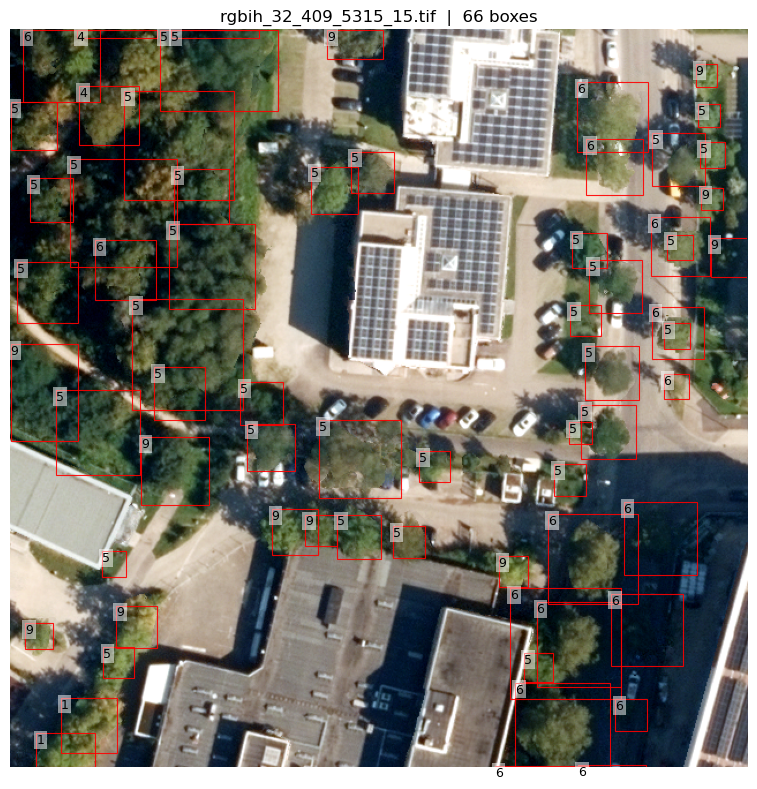

In [11]:
images_dir = Path("/mnt/sds-hd/sd17f001/ygrin/silverways/greenspaces/experiments_datasets/final_subtiles_640_20/yolo_rgbih/images/train")
labels_dir = Path("/mnt/sds-hd/sd17f001/ygrin/silverways/greenspaces/experiments_datasets/final_subtiles_640_20/yolo_rgbih/labels/train")

img = images_dir / "rgbih_32_409_5315_15.tif"
lbl = labels_dir / "rgbih_32_409_5315_15.txt"

show_chip_with_labels(img, lbl)

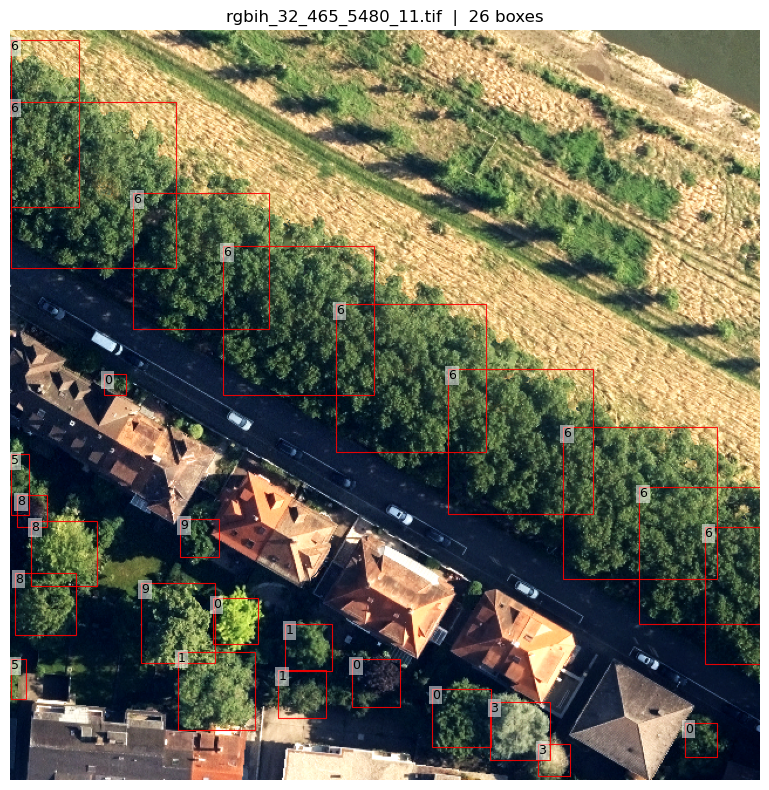

In [12]:
images = list(images_dir.glob("*.tif"))
img = random.choice(images)

lbl = labels_dir / f"{img.stem}.txt"

show_chip_with_labels(img, lbl)